# **1. Geçen haftaki MLP + BatchNorm modelini videodaki gibi küçük adımlara böl (logits, counts, probs, logprobs, ...) ve loss.backward() ile her ara değişkenin gradient'ini al. (Egzersiz 1, videonun ilk yarısı)**

In [4]:
# ilk baştaki hücreler geçen haftaki notebook'un aynısı

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [6]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [8]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [9]:
# üstteki kısımlar eski haftadan gelen kısımlardı

In [10]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [11]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [12]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [13]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3413, grad_fn=<NegBackward0>)

# **2. Aynı gradient'leri elle yaz, cmp fonksiyonuyla tek tek karşılaştır. Hepsi "exact" ya da "approximate" olana kadar devam et. Takıldığın türevi videoda bul, ama önce kendin dene.**

In [14]:
# 1 - burada mesela b1 birden fazla kez kullanıldığı için toplamamız gerekiyor. aynı mantıkla dcounts_sum_inv'de de toplamamız gerekiyor.

# c = a * b, but with tensors:
# a[3x3] * b[3x1] -->
# a11*b1 a12*b1 a13*b1
# a21*b2 a22*b2 a23*b2
# a31*b3 a32*b3 a33*b3
# c[3x3]

In [15]:
# 2 - burada b1'in (a11 a12 a13) dışındaki terimlere göre türevi 0 olacak. ama (a11 a12 a13) e göre türevi 1 olacak. o yüzden b1 türev matrisinde

# a11 a12 a13 --> b1 (= a11 + a12 + a13)
# a21 a22 a23 --> b2 (= a21 + a22 + a23)
# a31 a32 a33 --> b3 (= a31 + a32 + a33)

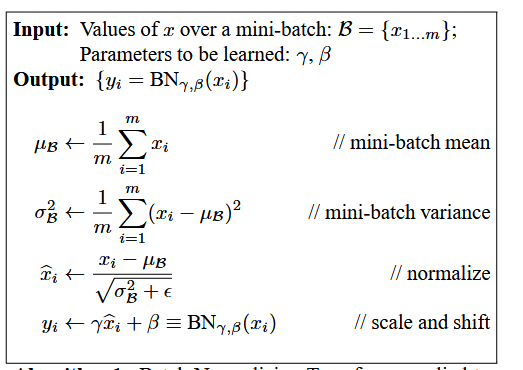

3 - Orijinal batch norm paper'ında (Ioffe & Szegedy, 2015) iki farklı adım var :

1- Eğitim sırasında mini-batch içindeki varyans m(batch boyutu) ile bölünerek hesaplanır. Bu, istatistikte yanlı (biased) tahmin edicidir.  

2- Test - inference sırasında model artık mini-batch görmez, eğitim boyunca biriktirilen hareketli ortalama varyans (running_var) kullanılır. Ancak makale, popülasyon varyansı hesaplanırken Bessel Düzeltmesi (Bessel's correction) yapılmasını söyler. Yeni varyans m/m-1 ile çarpılarak yansız (unbiased) hale getirilir. Test anında aktivasyonlar daha büyük varyansla bölünür.

İstatistikte bir popülasyon varyansını örneklem üzerinden tahmin ederken bu düzeltmeyi yapmak doğrudur. Ancak derin öğrenmedeki amaç istatistiksel tahmin yapmak değildir; amaç eğitimdeki dağılım ile testteki dağılımı birebir eşlemektir.

Test'e geldiğimizde birden sqrt(m/m-1) daha büyük varyans koyarsak aktivasyonlar test zamanında eğitime göre sqrt(m/m-1) kat daha kücük olur. Bir sonraki katmana giden sinyal eğitimde gördüğünden daha sönük gider.

Fakat bu çelişki m = 64 te sadece %0.8, m = 128'te sadece %0.4 fark yaratır. Zaten m = 2 veya 4 gibi boyutlar da seçilmez çünkü varyans gürültüden dolayı çöker. Bu yüzden küçük batch gerektiren yerlerde LayerNorm veya GroupNorm kullanılır.

LLM'ler, Transformer'lar ve modern Vision Transformer'lar gibi yeni ve gelişmiş modellerde batchnorm neredeyse hiç kullanılmıyormuş. Çünkü batchnorm dikey normalizasyon yaparken, layernorm yatay normalizasyon yapıyor. Ve bu outlierlar'ın diğer örnekleri kirletmesinin önüne geçiyor çünkü her örnek kendi bazında normalize oluyor. Aynı zamanda layernorm'da batchnormdaki gibi running_mean ve running_var olmadığı için, trainde hangi formül kullanılıyorsa testte de aynı formül kullanılır ve train test kayması sıfır olur.

Ekstra olarak; batch boyutuna bağlılığın bitmesi, dizi uzunlukları esnekliği gibi birtakım avantajlar daha sağlaması nedeniyle layernorm batchnorm'dan daha iyi bir yöntemmiş.

Hatta şu an en popüler olan RMSNorm'muş. Bunları merakımdan dolayı araştırdım :)

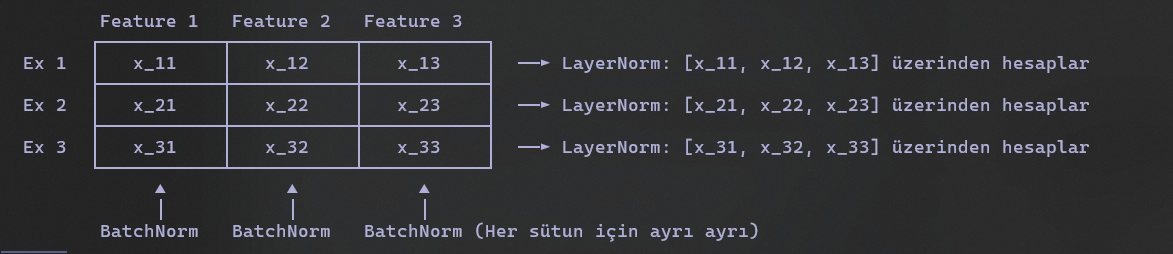

#4 Burada for döngüsü ile dC[ix]'lerin toplanmasının sebebi :

bir mini-batch içinde aynı harf birden fazla kez kullanılabilir. Örneğin 'a' harfi (C[1]) 1. kelimenin 1. harfi ve 3. kelimenin 4. harfi olabilir. Forward pass'te C[1] satırı ağın içine birden fazla branch ile girmiştir. Bu yüzden geriye doğru gelirken o yerlerden gelen gradların toplanması gerekir. Bu for döngüsü de bunu yapıyor.  

In [35]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # 1 - burada broadcasting yapıldığı icin dikkat
dcounts = counts_sum_inv * dprobs #counts birden fazla yerde kullanıldgıı icin
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv # (d/dx(1/x) = -1/(x**2))
dcounts += torch.ones_like(counts) * dcounts_sum # 2 - counts birden fazla yerde kullanıldığı için, 2 yerden gelen türevleri topluyoruz.
dnorm_logits = counts * dcounts # burada counts yazmamızın sebebi e**x'in türevi e**x. yani aslında dnorm_logits = norm_logits.exp() * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = -1 * dnorm_logits.sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes # biz max olan sayıyı 0.00001 artırırsak sonuc 0.00001 degisir, o yuzden onun turevi 1. digerlerini cok az arttırsak bile max olan deger degismeyecegi icin, digerlerinin turevi 0. o yüzden onehot encoding ile maxları 1 diğerlerini 0 yapan matrisi kuruyoruz.
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh # d/dx(tanh(x)) = (1-tanh(x)**2)
dbngain = (bnraw * dhpreact).sum(0, keepdim=True) #bngain row vector oldugu icin forward pass sırasında replike ediliyor. o yüzden grad hesaplarken toplamamız gerekiyor.
dbnraw = bngain * dhpreact # bu zaten (32,64) o yüzden toplamıyoruz.
dbnbias = dhpreact.sum(0, keepdim=True) #bu da row vector yani (1,64) olduğu icin topluyoruz.
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar # 3
dbndiff += 2 * bndiff * dbndiff2
dbnmeani = (-dbndiff).sum(0)
dhprebn = dbndiff.clone()
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]): #4
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
bngain          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnbias          | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09
bnraw   